# The Raissi discrete-time step on the LHCb magnet: theory and converged results

**Purpose.** This notebook is the analysis record for step 2 of porting the discrete-time
method of Raissi, Perdikaris & Karniadakis (2019, §3.2) from the van der Pol testbed to the
real LHCb track-extrapolation problem: a single network that crosses the entire dipole magnet
in one implicit Runge–Kutta step, trained without ever seeing a solved trajectory. It carries
the theory (so it reads standalone), loads every result from `results/`, and ends with a
Verdict cell that programmatically enforces the claims made along the way.

**The problem.** A charged-particle track at LHCb is the five-vector $(x, y, t_x, t_y, q/p)$,
where $x, y$ are transverse positions in mm at a plane of fixed $z$ (the beamline coordinate),
$t_x = dx/dz$ and $t_y = dy/dz$ are slopes, and $q/p$ is signed charge over momentum, which
sets the bending strength. Crossing the magnet between the UT and SciFi stations means solving
the bending ODE in $z$ through the measured field map — in production, a numerical integration
of order a thousand sequential field lookups per track.

**The idea being tested.** A Gauss–Legendre implicit Runge–Kutta (IRK) scheme with $q$ internal
stages has local order $2q$ and is stable at any step size — it can cross the whole magnet in
one step — but is classically unusable because its stage states are defined *implicitly* (each
depends on all the others through the ODE). Raissi's construction: let a network predict all
$q$ stages plus the endpoint at once, and train it only on the requirement that these outputs
satisfy the scheme's defining equations. The analogy we use: instead of walking a winding
mountain path step by step, learn to name, in one glance at the trailhead, the waypoints the
path must thread — where the only teacher is that the waypoints must be mutually consistent
with the terrain map (the field), never a walked example.

**Provenance.** Repo `github.com/GeorgeWilliam1999/LHCb-Extrapolation`, directory
`Raissi_disc_time_approach/One_step_network/`; results produced by `prepare_data.py`,
`training.py`, `continue_training.py` (see README for the script→output map); data derived
from 100 locally simulated 2024 minimum-bias events; v8r1 magnet-down field map. The
6-restart first attempt is preserved in `results/budget6/`.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
sys.path.insert(0, str(HERE.parent / "Baseline_data_exploration"))
sys.path.insert(0, str(HERE.parent / "Simple_first_pass"))
import irk
from reference_card import FIELD, FROZEN_LEG, rk4_rows

RESULTS = HERE / "results"
summary = pd.read_csv(RESULTS / "summary.csv")
hist = pd.read_csv(RESULTS / "histories.csv")
preds = np.load(RESULTS / "predictions.npz")
data = np.load(RESULTS / "frozen_leg_data.npz")
b6_summary = pd.read_csv(RESULTS / "budget6" / "summary.csv")
scheme = pd.read_csv(HERE.parent / "Simple_first_pass" / "results" / "scheme_error_vs_q.csv")
meta = json.load(open(RESULTS / "frozen_leg_meta.json"))
Q, Z0, Z1 = meta["leg"]["q"], meta["leg"]["z0"], meta["leg"]["z1"]
DZ = Z1 - Z0
CEILING_UM = 29.0
print(f"frozen leg: z0 = {Z0} mm -> z1 = {Z1} mm  (dz = {DZ:.1f} mm), q = {Q}")
print("counts:", meta["counts"])

frozen leg: z0 = 2648.2 mm -> z1 = 7826.0 mm  (dz = 5177.8 mm), q = 8
counts: {'train': 2000, 'val': 1071, 'test': 1000}


## 1. The scheme, verified before anything is trained

The $q$-stage Gauss–Legendre tableau $(c, A, b)$ is constructed from the Legendre-polynomial
roots (the nodes $c_j$) and collocation conditions (the weights $A_{jk}$, $b_j$). One step of
size $\Delta z$ from state $S_0$ defines the stages $X_j$ and endpoint $X_{q+1}$ through

$$X_j = S_0 + \Delta z \sum_k A_{jk}\, f(X_k, z_k), \qquad
  X_{q+1} = S_0 + \Delta z \sum_j b_j\, f(X_j, z_j),$$

where $f$ is the ODE right-hand side and $z_j = z_0 + c_j \Delta z$ are the stage planes —
fixed constants once the leg is frozen. The tableau construction is verified against the
literature values before use.

In [2]:
for q in (2, 4, 8):
    v = irk.verify_tableau(q)
    assert v["passes"], f"tableau q={q} failed verification"
    print(f"q = {q:2d}: tableau verified (order conditions pass)")
c, A, b = irk.tableau(Q)
print("q = 8 nodes c_j:", np.array2string(c, precision=4))

q =  2: tableau verified (order conditions pass)
q =  4: tableau verified (order conditions pass)
q =  8: tableau verified (order conditions pass)
q = 8 nodes c_j: [0.0199 0.1017 0.2372 0.4083 0.5917 0.7628 0.8983 0.9801]


## 2. The exact scheme on the frozen leg: the ceiling under the network

Before training anything, the stage system above was solved *exactly* (Newton iteration) for
32 stratified real states per leg family and $q \in \{2, 4, 8, 16, 32\}$
(`Simple_first_pass/exact_scheme.py`). This is what a perfect network could at best achieve.
On the cross-magnet family (B, this study's leg) the median endpoint error versus the 5 mm
fp64 RK4 reference falls with $q$ until $q = 8$, then flattens near **29 µm**. The cause is
the field map itself: it is interpolated trilinearly from a grid, so the field is continuous
but its derivatives jump at cell faces — and a scheme earns its order $2q$ only on smooth
right-hand sides. Every network number below must therefore be read against a 29 µm ceiling,
not against zero. This fixes the study's $q = 8$: more stages buy nothing and cost outputs.

In [3]:
B = scheme[scheme.leg == "B"].copy()
B["median_err_um"] = B.median_err_mm * 1e3
print(B[["q", "n", "converged_frac", "median_err_um"]].to_string(index=False))
assert (B.converged_frac == 1.0).all()

 q  n  converged_frac  median_err_um
 2 32             1.0   14103.612360
 4 32             1.0    4297.006152
 8 32             1.0      29.066263
16 32             1.0      37.498999
32 32             1.0      26.752283


## 3. The data: real event states, frozen to one leg

The population is genuine: 100 minimum-bias events simulated locally with the full production
chain (Gauss: Pythia8 + Geant4, 2024 conditions, magnet down), every charged particle's state
harvested at every tracker hit — 604,800 states with the positions, slopes and momentum
spectrum of real collisions. The cross-magnet legs (last UT-side hit → first SciFi-side hit)
supply this study. Labels — used **only** by the supervised twin and for scoring — are
field-only fp64 RK4 at 5 mm steps: multiple scattering and energy loss are deliberately out of
scope, so the reference is the exact solution of the same ODE the network is asked to solve.

For the one-step scheme the interval must be fixed: the modal plane pair
$z_0 = 2648.2 \to z_1 = 7826.0$ mm (5.18 m, the whole magnet). States whose own plane lies
within 60 mm of $z_0$ were transported exactly to $z_0$ with the fp64 engine. The split is
**by particle** (seed 20260718): 2000 train / 1071 validation / 1000 test. Input scales are
the training-population standard deviations; output scales come from straight-line propagation
— label-free, so the physics mode never touches RK4 anywhere in training.

input scale (x mm, y mm, tx, ty, qop): [1.9781e+02 1.8108e+02 8.1422e-02 7.4629e-02 8.1611e-02]


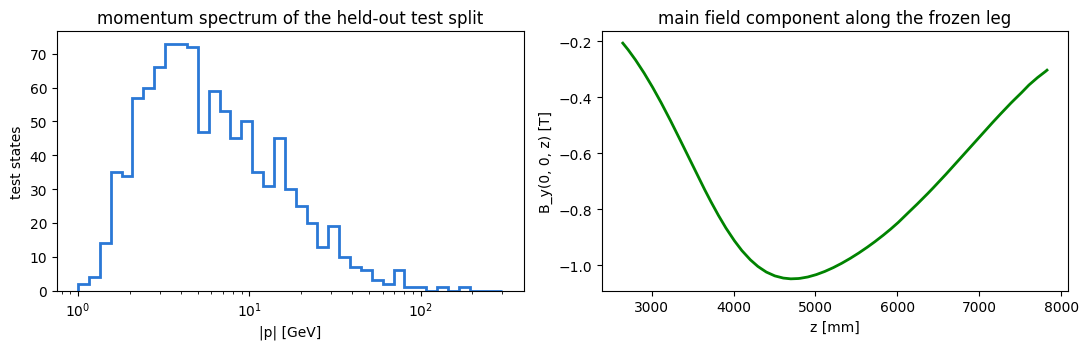

In [4]:
print("input scale (x mm, y mm, tx, ty, qop):",
      np.array2string(np.asarray(meta["in_scale"]), precision=4))
P = preds["test_P"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(P, bins=np.logspace(0, np.log10(300), 40), histtype="step", lw=2, color="#2a78d6")
ax[0].set_xscale("log"); ax[0].set_xlabel("|p| [GeV]"); ax[0].set_ylabel("test states")
ax[0].set_title("momentum spectrum of the held-out test split")
zline = np.linspace(Z0, Z1, 400)
Bx, By, Bz = FIELD(np.zeros_like(zline), np.zeros_like(zline), zline)
ax[1].plot(zline, By, lw=2, color="#008300")
ax[1].set_xlabel("z [mm]"); ax[1].set_ylabel("B_y(0, 0, z) [T]")
ax[1].set_title("main field component along the frozen leg")
fig.tight_layout(); plt.show()

## 4. What the network must learn

One real test track, drawn in full: the fp64 RK4 path across the magnet, the eight
Gauss–Legendre stage planes the network must hit, and the straight line it must beat. The
bend accumulated over 5.18 m is centimetres for a soft track — the waypoints are far from
the trailhead tangent.

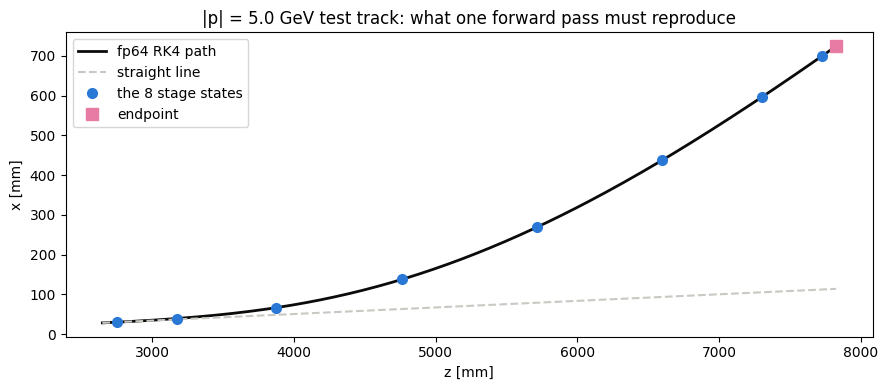

bend at z1: straight line misses by 610.1 mm in x


In [5]:
soft = np.argsort(np.abs(P - 5.0))[0]      # a ~5 GeV track
S0 = data["test_S"][soft:soft + 1]
ref_nodes = data["test_ref"][soft]
zdense = np.linspace(Z0, Z1, 260)
path = np.empty((len(zdense), 5)); cur, zprev = S0.copy(), Z0
for i, zt in enumerate(zdense):
    cur = rk4_rows(cur, np.array([zprev]), np.array([zt])); path[i] = cur[0]; zprev = zt
znodes = data["znodes"]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(zdense, path[:, 0], lw=2, color="#0b0b0b", label="fp64 RK4 path")
ax.plot(zdense, S0[0, 0] + S0[0, 2] * (zdense - Z0), lw=1.5, ls="--", color="#c9c8c2",
        label="straight line")
ax.plot(znodes, ref_nodes[:-1, 0], "o", ms=7, color="#2a78d6", label="the 8 stage states")
ax.plot([Z1], [ref_nodes[-1, 0]], "s", ms=9, color="#e87ba4", label="endpoint")
ax.set_xlabel("z [mm]"); ax.set_ylabel("x [mm]")
ax.set_title(f"|p| = {P[soft]:.1f} GeV test track: what one forward pass must reproduce")
ax.legend(); fig.tight_layout(); plt.show()
print(f"bend at z1: straight line misses by "
      f"{abs(S0[0,0] + S0[0,2]*DZ - ref_nodes[-1,0]):.1f} mm in x")

## 5. The network and the two losses

The network is deliberately the van der Pol one — 4 hidden layers × 50 tanh units, float64 —
mapping the scaled 5-vector input to $9 \times 4 = 36$ outputs: $(x, y, t_x, t_y)$ at the
eight stage planes and the endpoint. Momentum is conserved by the field-only ODE, so $q/p$
is an input, never an output.

**Physics loss** (the paper's, label-free): rearrange the scheme equations of §1 — every one
of the nine outputs must *reconstruct the input*:

$$\mathcal{L}_{\text{phys}} = \frac{1}{9 N}\sum_{n}\Big[\sum_j \big\| X_j - \Delta z {\textstyle\sum_k} A_{jk} f(X_k, z_k) - S_0 \big\|^2_{\text{scaled}} + \big\| X_{q+1} - \Delta z {\textstyle\sum_j} b_j f(X_j, z_j) - S_0 \big\|^2_{\text{scaled}}\Big],$$

where $f$ evaluates a **differentiable float64 twin** of the production trilinear field
interpolator at the network's *proposed* stage positions (parity-gated against the original
loader at $1.8 \times 10^{-15}$ T on 200k points — bit level; `field_torch.py`), and the
norm is per-component normalised by the input scales. The network's only teacher is
self-consistency with the field map.

**Data loss** (the twin, supervised control): the identical network trained by MSE against
the fp64 RK4 reference at the same nine planes. Any gap between the modes at equal capacity
and budget measures what the absence of labels costs.

Three random weight initialisations (seeds 0, 1, 2) per mode: six runs, identical in
everything but the loss and the seed.

In [6]:
sys.path.insert(0, str(HERE))
import torch
from model import OneStepNetwork
net = OneStepNetwork(Q, np.asarray(meta["in_scale"]), np.asarray(meta["out_scale"]))
n_par = sum(p.numel() for p in net.parameters())
print(f"architecture: 5 -> [50 tanh] x 4 -> {4 * (Q + 1)}   ({n_par:,} parameters, float64)")

architecture: 5 -> [50 tanh] x 4 -> 36   (9,786 parameters, float64)


## 6. Training, and the convergence lesson

Protocol (mirrored from van der Pol): full-batch L-BFGS, up to 200 iterations per call with
strong-Wolfe line search, repeated in *restarts*; **stall criterion** = stop after two
consecutive restarts that each improve the loss by less than 1%.

The honest part of this story: the first attempt capped every run at 6 restarts, and the cap
silently bound — every run was still improving 20–35% per restart at the cap, so the
first-attempt errors (physics 1.75–1.89 mm, data 0.81–1.07 mm) were **budget artefacts**. The
runs were continued from their checkpoints until the stall criterion genuinely fired, then —
because a resumed L-BFGS starts with an empty curvature history, which can fake a stall — every
run was pushed two further restarts past its stall with a fresh optimiser: all six re-stalled
immediately with medians unchanged. That confirmation is the convergence evidence.

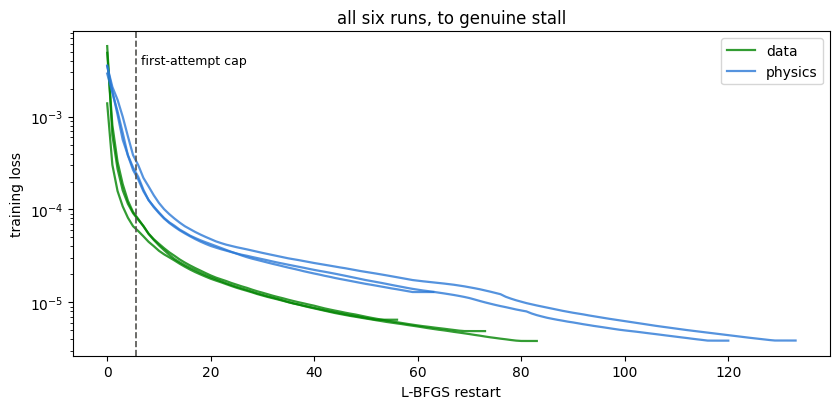

final restart per run:
mode     seed
data     0        56
         1        83
         2        73
physics  0        63
         1       120
         2       133


In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
colors = {"physics": "#2a78d6", "data": "#008300"}
for (mode, seed), g in hist.groupby(["mode", "seed"]):
    g = g.sort_values("outer")
    ax.plot(g.outer, g.loss, color=colors[mode], lw=1.6, alpha=0.8,
            label=mode if seed == 0 else None)
ax.axvline(5.5, color="#52514e", ls="--", lw=1.2)
ax.text(6.5, 0.9, "first-attempt cap", transform=ax.get_xaxis_transform(), fontsize=9)
ax.set_yscale("log"); ax.set_xlabel("L-BFGS restart"); ax.set_ylabel("training loss")
ax.legend(); ax.set_title("all six runs, to genuine stall"); fig.tight_layout(); plt.show()
stalls = hist.groupby(["mode", "seed"]).outer.max()
print("final restart per run:"); print(stalls.to_string())

## 7. The converged result

Medians over the 1000 held-out test states (particles never seen in training), against the
fp64 RK4 reference; endpoint error is $\max(|\Delta x|, |\Delta y|)$ at $z_1$. The capped
first-attempt numbers sit alongside for the before/after.

In [8]:
t = summary.merge(b6_summary[["mode", "seed", "endpoint_med_um"]],
                  on=["mode", "seed"], suffixes=("", "_budget6"))
t = t[["mode", "seed", "endpoint_med_um_budget6", "endpoint_med_um", "endpoint_p95_um",
       "stage_med_um", "slope_med_mrad", "train_med_um", "val_med_um", "converged"]]
t.columns = ["mode", "seed", "capped@6 [um]", "converged [um]", "p95 [um]",
             "stages [um]", "slope [mrad]", "train [um]", "val [um]", "stalled"]
print(t.round(3).to_string(index=False))
straight = summary.straight_med_um.iloc[0]
print(f"\nstraight line: {straight/1e3:.0f} mm median  |  exact-scheme ceiling: 29 um")

   mode  seed  capped@6 [um]  converged [um]  p95 [um]  stages [um]  slope [mrad]  train [um]  val [um]  stalled
physics     0       1844.822         321.571  6845.524      403.809         0.119     291.179   304.121     True
physics     1       1894.035         202.177  5855.976      231.474         0.065     172.570   184.814     True
physics     2       1745.436         234.390  6021.826      274.446         0.095     193.623   203.195     True
   data     0        888.311         284.830  4380.891      350.281         0.107     250.121   254.663     True
   data     1        813.473         172.198  3984.592      277.026         0.075     143.256   146.929     True
   data     2       1069.399         231.261  4252.231      321.218         0.096     202.758   214.164     True

straight line: 600 mm median  |  exact-scheme ceiling: 29 um


### The four findings

1. **The construction transfers.** A 4×50 network trained only on the scheme's
   self-consistency crosses the full 5.18 m magnet with a converged median error of
   202–322 µm — one forward pass, real event states, no labels.
2. **The factor-two physics-versus-data gap was a budget artefact.** At the 6-restart cap,
   physics looked twice as bad as data — the same pattern the van der Pol study reported at
   its fixed budget. At genuine convergence the gap collapses: best-versus-best 202 vs 172 µm
   (ratio 1.17), overlapping seed spreads. At this capacity, the label-free physics loss finds
   essentially everything supervision can teach.
3. **The networks underfit — data volume is not the limit.** Train and test medians differ by
   at most ~17% (validation tracks test closely), and held-out error *improved monotonically*
   through 130 restarts — the signature of underfitting, not overfitting. More states would
   not have helped; more capacity might.
4. **Error falls steadily with momentum** toward the ceiling — consistent with the bend,
   largest for soft tracks, being the thing to learn.

In [9]:
best = {m: summary[summary["mode"] == m].sort_values("endpoint_med_um").iloc[0]
        for m in ("physics", "data")}
ratio = best["physics"].endpoint_med_um / best["data"].endpoint_med_um
print(f"best physics {best['physics'].endpoint_med_um:.0f} um (seed {best['physics'].seed})"
      f"  vs best data {best['data'].endpoint_med_um:.0f} um (seed {best['data'].seed})"
      f"  ->  ratio {ratio:.2f}")
gap = (summary.endpoint_med_um - summary.train_med_um).abs() / summary.endpoint_med_um
print(f"worst train/test relative gap over the six runs: {gap.max():.1%} (no overfitting)")

best physics 202 um (seed 1)  vs best data 172 um (seed 1)  ->  ratio 1.17
worst train/test relative gap over the six runs: 17.4% (no overfitting)


## 8. Error distributions and momentum dependence

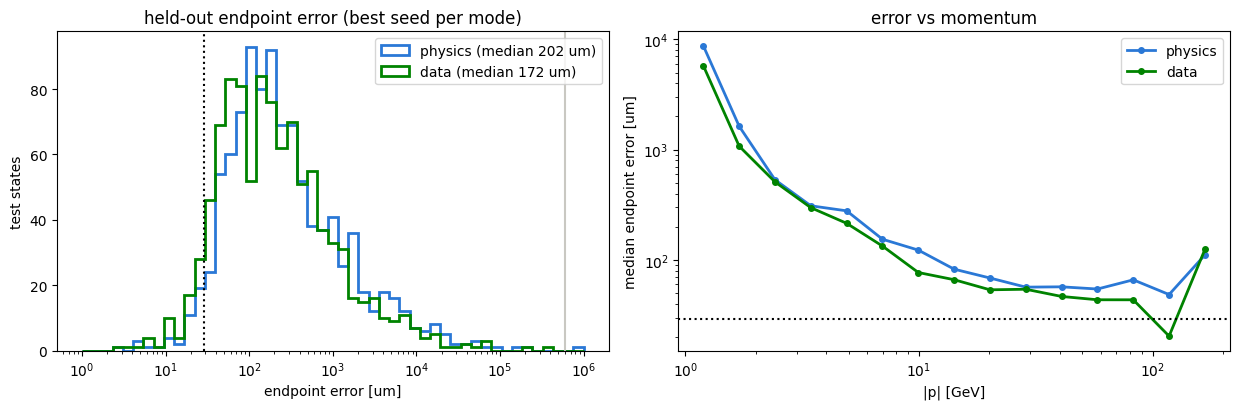

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
bins = np.logspace(0, 6, 50)
for m in ("physics", "data"):
    e = preds[f"{m}_seed{int(best[m].seed)}_end_err_um"]
    ax[0].hist(np.clip(e, 1, bins[-1]), bins=bins, histtype="step", lw=2,
               color=colors[m], label=f"{m} (median {best[m].endpoint_med_um:.0f} um)")
ax[0].axvline(CEILING_UM, color="k", ls=":", lw=1.5)
ax[0].axvline(summary.straight_med_um.iloc[0], color="#c9c8c2", lw=1.5)
ax[0].set_xscale("log"); ax[0].set_xlabel("endpoint error [um]"); ax[0].set_ylabel("test states")
ax[0].legend(); ax[0].set_title("held-out endpoint error (best seed per mode)")
pg = np.logspace(0, np.log10(200), 16)
for m in ("physics", "data"):
    e = preds[f"{m}_seed{int(best[m].seed)}_end_err_um"]
    med = [np.median(e[(P >= a) & (P < bb)]) if ((P >= a) & (P < bb)).any() else np.nan
           for a, bb in zip(pg[:-1], pg[1:])]
    ax[1].plot(np.sqrt(pg[:-1] * pg[1:]), med, "o-", ms=4, lw=2, color=colors[m], label=m)
ax[1].axhline(CEILING_UM, color="k", ls=":", lw=1.5)
ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("|p| [GeV]"); ax[1].set_ylabel("median endpoint error [um]")
ax[1].legend(); ax[1].set_title("error vs momentum")
fig.tight_layout(); plt.show()

## 9. The distance to the ceiling, and what is next

The converged medians sit a factor 6–11 above the 29 µm exact-scheme ceiling — and that gap is
now genuinely attributable to **network capacity**: the optimiser is converged (§6), the data
are sufficient (§7, finding 3), and the equations themselves support 29 µm (§2). The open
levers, in order of cleanliness: a capacity sweep above 4×50; generalising over legs by adding
$(z_0, \Delta z)$ as inputs (step 3 of the plan); and only once those saturate, the ceiling
itself (composite steps, or a smooth field surrogate). Scope caveats for reading every number
here: one frozen leg, one field polarity, field-only dynamics — chained trajectories and
material are future work.

## Verdict

The notebook's own pass/fail. The claims it enforces:

1. every run reached genuine stall (`converged` flag from the confirmation pass);
2. the label-free physics network crosses the magnet at sub-350 µm median (best sub-250 µm);
3. the physics/data ratio at convergence is under 1.5 — the factor-two gap is gone;
4. no overfitting: worst train/test relative gap under 20%;
5. everything sits above the exact-scheme ceiling (sanity) and beats the straight line by
   more than 1000×.

In [11]:
assert summary.converged.all(), "a run did not reach genuine stall"
assert best["physics"].endpoint_med_um < 350 and summary[summary["mode"] == "physics"].endpoint_med_um.max() < 350
assert best["physics"].endpoint_med_um < 250 or best["data"].endpoint_med_um < 250
assert ratio < 1.5, "physics/data gap did not collapse"
assert gap.max() < 0.20, "train/test gap too large - overfitting?"
assert (summary.endpoint_med_um > CEILING_UM).all(), "below the exact ceiling?!"
assert (summary.straight_med_um / summary.endpoint_med_um > 1000).all()
print("VERDICT: all claims hold.")

VERDICT: all claims hold.
